 Visualization 2 - Seaborn -scatter/bar, distributions,categorical

Seaborn is built on top of matplotlib - its a wrapper that handles a lot of tedious setup (grouping, coloring by category, computing statistics) automatically. So you write less code ffor the same-often better looking result

In [1]:
import os
os.chdir("Data Sets")

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("all_athlete_games.csv",low_memory=False)

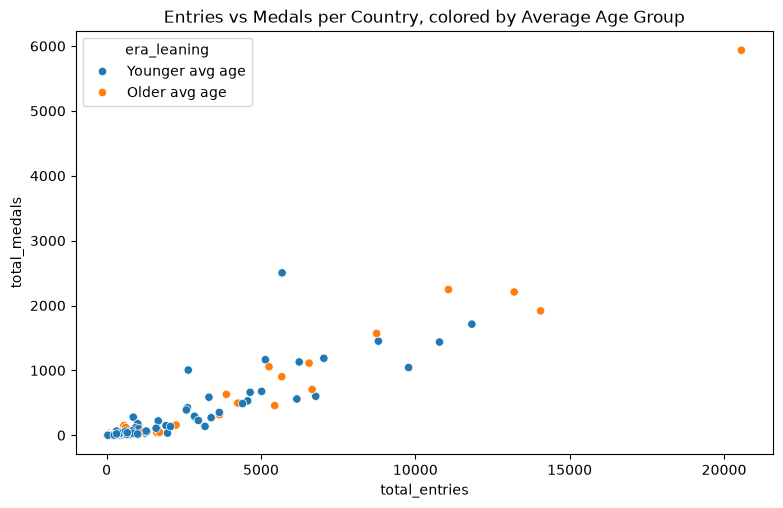

In [3]:
# Seaborn Wrapper

# sns.scatterplot, sns.barplot

# sns.scatterplot - like matplotlib's scatter but with easy category coloring

# sns.scatterplot(data=df,x=col,y=col,hue=category_col,ax=ax)

noc_summary = df.groupby("NOC").agg(
    total_entries=("Entry ID","count"),
    total_medals=("Medal", lambda x: x.notna().sum()),
    avg_age=("Age","mean")
).reset_index()
noc_summary = noc_summary[noc_summary["total_entries"] > 20]
noc_summary["era_leaning"] = noc_summary["avg_age"].apply(lambda a: "Older avg age" if a > 26 else "Younger avg age")

fig, ax = plt.subplots(figsize=(9,5.5))
sns.scatterplot(data=noc_summary, x="total_entries", y="total_medals", hue="era_leaning", ax=ax)
ax.set_title("Entries vs Medals per Country, colored by Average Age Group")
plt.show()

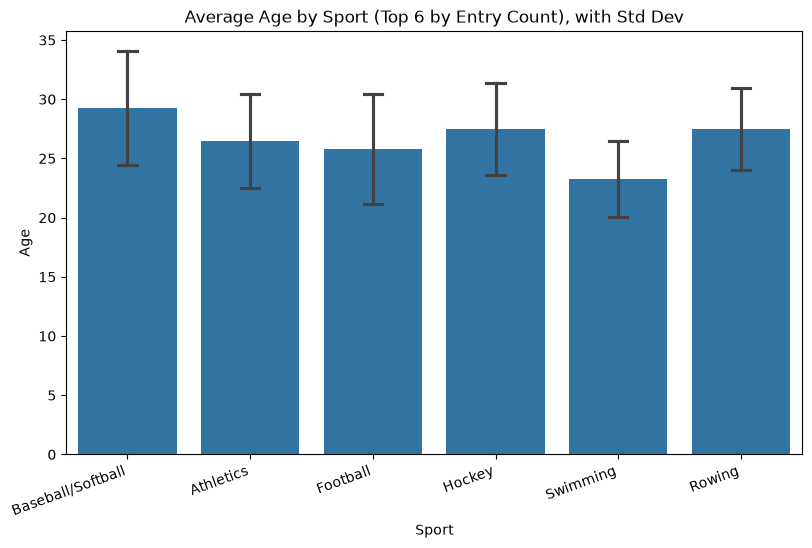

In [4]:
# sns.barplot() - automatically aggregates raw data and shows uncertainity

# syntax - sns.barplot(data=df,x=category_col,y=numeric_col,errorbar="sd",ax=ax)

sample = df[(df["Year"]==2020) & (df["Medal"].notna())][["Name","Age","Sport"]].dropna(subset=["Age"])
top_sports = sample["Sport"].value_counts().head(6).index.tolist()
subset = sample[sample["Sport"].isin(top_sports)]

fig, ax = plt.subplots(figsize=(9.5,5.5))
sns.barplot(data=subset, x="Sport", y="Age", ax=ax, errorbar="sd", capsize=0.15)
ax.set_title("Average Age by Sport (Top 6 by Entry Count), with Std Dev")
plt.xticks(rotation=20, ha="right")
plt.show()

# one bar per sport, each bar's height showing the average age with a vertical error bar line showing + or -1 standard deviation

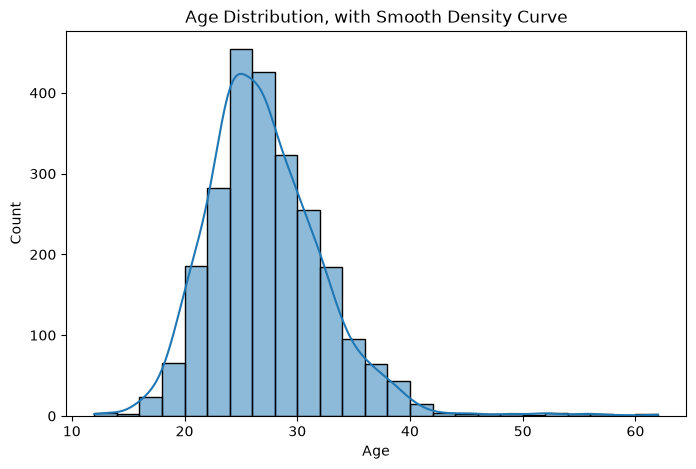

In [5]:
# Distributions - sns.histplot(), sns.kdeplot()

# sns.histplot() - histograms with an optional smooth curve built in

# sns.histplot(data=df,x=col,bins=N,kde=True/False,ax=ax)

sample = df[(df["Year"]==2020) & (df["Medal"].notna())][["Name","Age"]].dropna()

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=sample, x="Age", bins=25, kde=True, ax=ax)
ax.set_title("Age Distribution, with Smooth Density Curve")
plt.show()

# kde=True overlays a KDE (kernel Density Estimate) - a smooth version of the histogram shape - directly on top. This makes the overall shape of 
# the distribution (the right skew the long tail toward older ages) easier to read than bars alone, especially with a smaller number of bins.

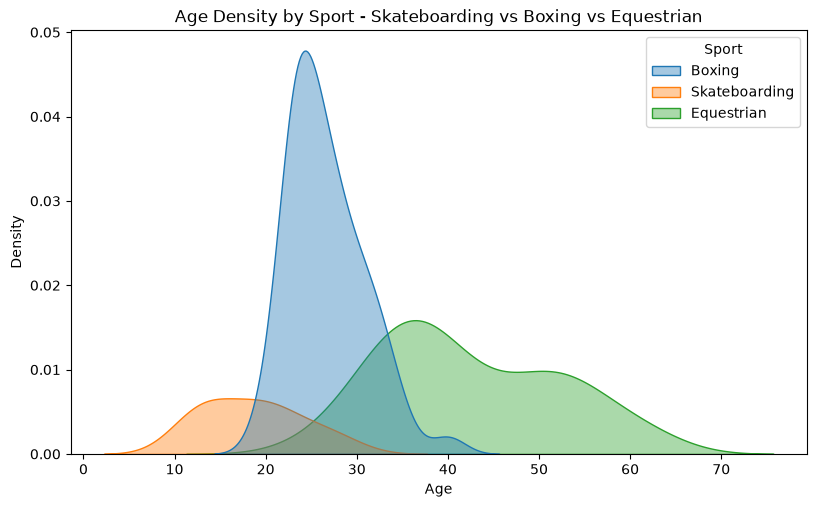

In [6]:
# sns.kdeplot - (the smooth curve on its own, grate for comparing groups)

# sns.kdeplot(data=df,x=col,hue=category_col,fill=True,ax=ax)

sample= df[(df["Year"]==2020) & (df["Medal"].notna())][["Name","Age","Sport"]].dropna()

compare = sample[sample["Sport"].isin(["Skateboarding","Equestrian","Boxing"])]

fig, ax = plt.subplots(figsize=(9.5,5.5))
sns.kdeplot(data=compare, x="Age", hue="Sport", fill=True, alpha=0.4, ax=ax)
ax.set_title("Age Density by Sport - Skateboarding vs Boxing vs Equestrian")
plt.show()

# Three overlaping smooth curves - Skateboarding sharply peaked around the young teens, Boxing peaked tightly around the mis - 20s and 
# Equestrian spread widely accross a much older range(30's to 60's+)

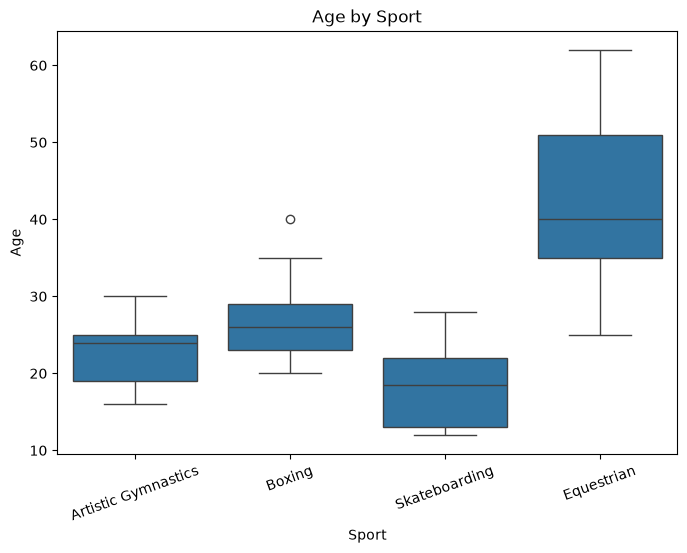

In [7]:
# Categorical - sns.boxplot(), sns.violinplot()

# sns.boxplot(data=df, x=category_col,y=numeric_col,ax=ax)

compare = sample[sample["Sport"].isin(["Skateboarding","Artistic Gymnastics","Boxing","Equestrian"])]

fig, ax = plt.subplots(figsize=(8,5.5))
sns.boxplot(data=compare, x="Sport", y="Age", ax=ax)
ax.set_title("Age by Sport")
plt.xticks(rotation=20)
plt.show()

# four plots side by side -  showing median, IQR box, whiskers and any outlier dots for each sport

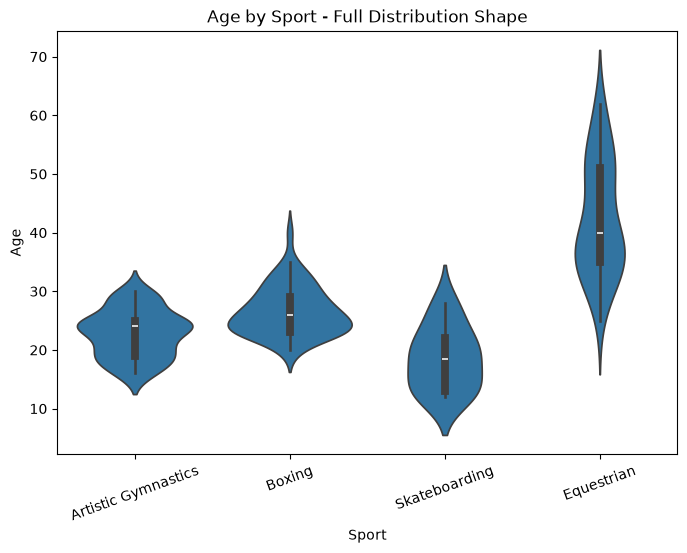

In [8]:
# sns.violinplot() - the same comparision but showing full distribution shape 

# sns.violinplot(data=df,x=category_col,y=nummeric_col,ax=ax)

fig, ax = plt.subplots(figsize=(8,5.5))
sns.violinplot(data=compare, x="Sport", y="Age", ax=ax)
ax.set_title("Age by Sport - Full Distribution Shape")
plt.xticks(rotation=20)
plt.show()

# four violin shapes - wider where more athletes cluster at that age, narrower where fewer do - with a small box plot embedded inside each one.